# PFO Data Preprocessing

---
Train/test split

Scale per event window

In [1]:
%%time
import sys, time, shutil
#-----------------------------------------------------------------------------------------------------------------#
# Command to make all plots interactive
%matplotlib ipympl
#-----------------------------------------------------------------------------------------------------------------#
# Import packages as
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#-----------------------------------------------------------------------------------------------------------------#
# From package import function
from obspy import read, Trace
from pathlib import Path
from fractions import Fraction
from scipy.signal import butter, sosfiltfilt
from sklearn.model_selection import train_test_split
from scipy.signal import butter, sosfiltfilt, detrend, windows
#-----------------------------------------------------------------------------------------------------------------#
# Download dataset from SSD
db_dir = Path("Database")
X = np.load(db_dir / "waveforms.npy")  # [N, C, S, T]
meta_df = pd.read_pickle(db_dir / "event_meta.pkl").reset_index(drop=True)
print("Number of events:", X.shape[0])
print("X shape [N, C, S, T]:", X.shape)
print("Current duration at 40 Hz:", X.shape[-1] / 40.0, "seconds")

Number of events: 30609
X shape [N, C, S, T]: (30609, 3, 10, 2400)
Current duration at 40 Hz: 60.0 seconds
CPU times: user 15.1 s, sys: 5.04 s, total: 20.1 s
Wall time: 24.1 s


---
Removing events that are below 2.0 Mag (dataset is now 30,000 with proportionately more events > 2 Mag)

In [2]:
%%time
# Remove 609 events among MAG < 2.0
# using EVIDs from the ranking spreadsheet, before train/test split.

ranking_path = "train_event_difficulty_ranking.csv"
ranking_df = pd.read_csv(ranking_path)

# Pick the 609 low-magnitude events
remove_df = (
    ranking_df.loc[ranking_df["MAG"] < 2.0]
    .sort_values("event_avg_corr", ascending=True)
    .head(609)
    .copy()
)

remove_evids = set(remove_df["EVID"].astype(str))

# Match against the full metadata table
meta_evid_str = meta_df["EVID"].astype(str)
remove_mask = meta_evid_str.isin(remove_evids)

print(f"\nMatches found in full dataset: {remove_mask.sum()}")

X_filtered = X[~remove_mask.to_numpy()]
meta_df_filtered = meta_df.loc[~remove_mask].reset_index(drop=True)

print(f"Original X shape: {X.shape}")
print(f"Filtered X shape: {X_filtered.shape}")
print(f"Original meta_df length: {len(meta_df)}")
print(f"Filtered meta_df length: {len(meta_df_filtered)}")
print(f"Removed {len(X) - len(X_filtered)} events")


Matches found in full dataset: 609
Original X shape: (30609, 3, 10, 2400)
Filtered X shape: (30000, 3, 10, 2400)
Original meta_df length: 30609
Filtered meta_df length: 30000
Removed 609 events
CPU times: user 489 ms, sys: 677 ms, total: 1.17 s
Wall time: 1.34 s


---
Bandpass filter, demean, and detrend

In [3]:
%%time
def refilter_waveforms_numpy(
    X,
    fs=40.0,
    freqmin=0.5,
    freqmax=5.0,
    order=4,
    trim_seconds=None,
    dtype=np.float32
):
    """
    X: [N, C, S, T]

    Applies:
        optional trim from the end, keeping first trim_seconds
        demean
        linear detrend
        zero-phase bandpass along time

    No taper. No resampling.
    """

    X_work = X.astype(np.float32, copy=False)

    if trim_seconds is not None:
        npts_keep = int(round(trim_seconds * fs))

        if X_work.shape[-1] < npts_keep:
            raise ValueError(
                f"Input has {X_work.shape[-1]} samples, but trim_seconds={trim_seconds} "
                f"at fs={fs} requires {npts_keep} samples."
            )

        # Keep first trim_seconds, trim from the end.
        X_work = X_work[..., :npts_keep]

    # Demean over time.
    X_work = X_work - np.mean(X_work, axis=-1, keepdims=True)

    # Linear detrend over time.
    X_work = detrend(X_work, axis=-1, type="linear")

    # Butterworth bandpass.
    sos = butter(
        order,
        [freqmin, freqmax],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    X_filt = sosfiltfilt(
        sos,
        X_work,
        axis=-1
    )

    return X_filt.astype(dtype)

CPU times: user 7 μs, sys: 0 ns, total: 7 μs
Wall time: 12.2 μs


In [5]:
%%time
X_05_5 = refilter_waveforms_numpy(
    X_filtered,
    fs=40.0,
    freqmin=0.5,
    freqmax=10.0, # IMPORTANT: change this to 5.0 to reproduce the 0.5 - 5 Hz band processed signals used for subsequent training and evaluation
    order=4,
    trim_seconds=None
)

print(X_05_5.shape, X_05_5.dtype)
print(np.nanmin(X_05_5), np.nanmax(X_05_5))

(30000, 3, 10, 2400) float32
-0.020015728 0.021555364
CPU times: user 3min 33s, sys: 1min, total: 4min 34s
Wall time: 1min 19s


---
Sanity check

In [5]:
%%time
def plot_event_waveforms(
    X,
    event_idx=0,
    station_order=None,
    components=None,
    fs=40.0,
    title=None,
    meta_df=None,
    bandpass=None,
    normalize_traces=False,
    figsize=(14, 9),
    linewidth=0.8
):
    """
    Plot all component/station waveforms for one event.

    X expected shape:
        [N, C, S, T]

    Example:
        plot_event_waveforms(
            X_05_5,
            event_idx=10,
            station_order=station_order,
            components=["BHZ", "BHN", "BHE"],
            fs=40.0,
            meta_df=meta_test,
            bandpass=[0.5, 5]
        )
    """

    x = X[event_idx]  # [C, S, T]

    n_comp, n_sta, n_time = x.shape
    t = np.arange(n_time) / fs

    if station_order is None:
        station_order = [f"S{i}" for i in range(n_sta)]

    if components is None:
        components = [f"C{i}" for i in range(n_comp)]

    fig, axes = plt.subplots(
        n_comp,
        1,
        figsize=figsize,
        sharex=True,
        constrained_layout=True
    )

    if n_comp == 1:
        axes = [axes]

    for ci, ax in enumerate(axes):
        traces = x[ci]  # [S, T]

        if normalize_traces:
            scale = np.max(np.abs(traces), axis=1, keepdims=True)
            scale = np.maximum(scale, 1e-12)
            traces_plot = traces / scale
        else:
            traces_plot = traces

        spacing = np.nanmax(np.abs(traces_plot))
        spacing = spacing if spacing > 0 else 1.0
        spacing *= 2.5

        for si in range(n_sta):
            offset = si * spacing
            ax.plot(
                t,
                traces_plot[si] + offset,
                linewidth=linewidth,
                color="black"
            )

        ax.set_yticks(np.arange(n_sta) * spacing)
        ax.set_yticklabels(station_order)
        ax.set_ylabel(components[ci])
        ax.grid(True, alpha=0.25)
        ax.set_xlim(0,60)

    axes[-1].set_xlabel("Time (s)")

    if title is None:
        if meta_df is not None:
            event_info = meta_df.iloc[event_idx]

            evid = event_info.get("EVID", event_info.get("ev_id", "NA"))
            date_str = event_info.get("YY/MM/DD", event_info.get("YYY/MM/DD", "NA"))
            mag = event_info.get("MAG", "NA")
            dist_km = event_info.get("distance_km", "NA")

            if pd.notna(mag):
                mag_str = f"{float(mag):.2f}"
            else:
                mag_str = "NA"

            if pd.notna(dist_km):
                dist_str = f"{float(dist_km):.1f} km"
            else:
                dist_str = "NA"

            title = f"EVID: {evid} | Date: {date_str} | Dist: {dist_str} | M: {mag_str}"
        else:
            title = f"Event {event_idx}"

    if bandpass is not None:
        title = f"{title} | Bandpass: {bandpass}"

    fig.suptitle(title)
    plt.show()

    return fig, axes

CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 6.2 μs


['BPH01', 'BPH02', 'BPH03', 'BPH06', 'BPH07', 'BPH08', 'BPH09', 'BPH10', 'BPH11', 'BPH13']


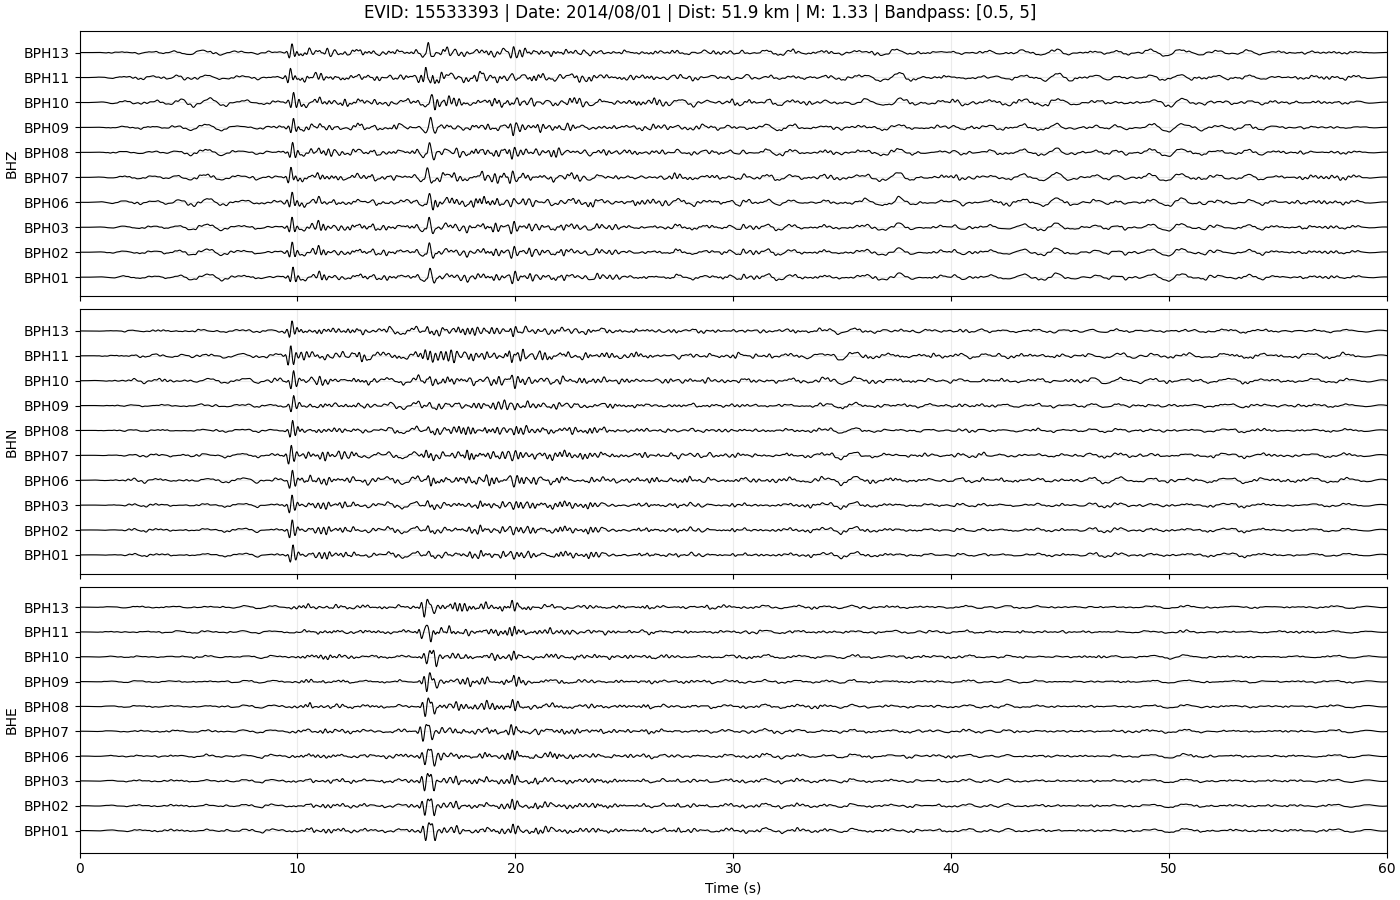

CPU times: user 1.07 s, sys: 28.5 ms, total: 1.1 s
Wall time: 1.12 s


In [6]:
%%time
stations_to_remove = {"BPH04", "BPH05", "BPH12"}

station_order = [
    f"BPH{i:02d}"
    for i in range(1, 14)
    if f"BPH{i:02d}" not in stations_to_remove
]

print(station_order)

fig, axes = plot_event_waveforms(
    X_05_5,
    event_idx=0,
    station_order=station_order,
    components=["BHZ", "BHN", "BHE"],
    fs=40.0,
    meta_df=meta_df_filtered,
    bandpass=[0.5, 10],
    normalize_traces=True
)
fig.savefig("Figures/Input_Array_Data_Example.png", dpi=300)

---
Coherence plots

In [5]:
%%time
# --------------------------------------------------
# Config
# --------------------------------------------------
components = ["BHZ", "BHN", "BHE"]
component_to_use = "BHZ"
comp_idx = components.index(component_to_use)

fs = 40.0
sample_n = X_05_5.shape[0] # use all events
random_seed = 42
eps = 1e-10

assert len(meta_df_filtered) == X_05_5.shape[0], "meta_df and X are not aligned"

# --------------------------------------------------
# Random sample of events
# --------------------------------------------------
rng = np.random.default_rng(random_seed)
n_total = X_05_5.shape[0]
n_use = min(sample_n, n_total)
sample_idx = np.sort(rng.choice(n_total, size=n_use, replace=False))

X_sub = X_05_5[sample_idx]
meta_sub = meta_df_filtered.iloc[sample_idx].reset_index(drop=True)

print(f"Using {n_use} randomly selected events out of {n_total}")

# --------------------------------------------------
# Helpers matching your correlation style
# --------------------------------------------------
def norm_xcorr(t_data, data1, data2):
    a = data1
    b = data2

    std_a = np.std(a)
    std_b = np.std(b)

    if std_a < eps or std_b < eps:
        return None, None

    a = (a - np.mean(a)) / (std_a * len(a))
    b = (b - np.mean(b)) / std_b
    x_corr = np.correlate(a, b, "full")
    lags = np.hstack((np.flipud(-t_data)[0:len(t_data)-1], t_data))

    return lags, x_corr

def fix_lengths(t, y):
    t_out = t.copy()
    y_out = y.copy()

    if len(t_out) > len(y_out):
        t_out = t_out[:len(y_out)]
    elif len(y_out) > len(t_out):
        y_out = y_out[:len(t_out)]

    return t_out, y_out

def event_full_window_coherence(data_array, fs):
    """
    data_array: [n_stations, n_samples]
    returns one scalar coherence value for the full event window
    """
    n_stations, n_samples = data_array.shape
    t = np.arange(0, n_samples / fs, 1.0 / fs)

    # Match your normalization before xcorr
    data_array_tmp = []
    for i in range(n_stations):
        x = data_array[i]
        mx = np.max(np.abs(x))
        if mx < eps:
            return np.nan
        data_array_tmp.append(x / mx)
    data_array_tmp = np.asarray(data_array_tmp)

    data_fixed = []
    for i in range(data_array_tmp.shape[0]):
        t_use, x_use = fix_lengths(t, data_array_tmp[i])
        data_fixed.append(x_use)
    data_fixed = np.asarray(data_fixed)

    station_means = []
    for tr_idx in range(data_fixed.shape[0]):
        tr_data_idx = data_fixed[tr_idx]
        tr_xcorr_coef = []

        for j in range(data_fixed.shape[0]):
            if j == tr_idx:
                continue

            _, xcorr_vals = norm_xcorr(t_use, tr_data_idx, data_fixed[j])
            if xcorr_vals is None:
                continue
            tr_xcorr_coef.append(np.max(xcorr_vals))

        if len(tr_xcorr_coef) > 0:
            station_means.append(np.mean(tr_xcorr_coef))

    if len(station_means) == 0:
        return np.nan

    return float(np.mean(station_means))

# --------------------------------------------------
# Compute one coherence value per event
# --------------------------------------------------
rows = []
n_events_sub = X_sub.shape[0]

for i in range(n_events_sub):
    event_data = X_sub[i, comp_idx, :, :]   # [n_stations, n_samples]
    meta = meta_sub.iloc[i]

    try:
        mean_corr = event_full_window_coherence(event_data, fs)
    except Exception:
        mean_corr = np.nan

    rows.append({
        "EVID": meta["EVID"],
        "mean_corr": mean_corr,
        "azimuth_deg": meta["azimuth_deg"],
        "distance_km": meta["distance_km"],
        "MAG": meta["MAG"],
    })

    print(f"done with event {i+1}/{n_events_sub}")

corr_df = pd.DataFrame(rows)
display(corr_df.head())

Using 30000 randomly selected events out of 30000
done with event 1/30000
done with event 2/30000
done with event 3/30000
done with event 4/30000
done with event 5/30000
done with event 6/30000
done with event 7/30000
done with event 8/30000
done with event 9/30000
done with event 10/30000
done with event 11/30000
done with event 12/30000
done with event 13/30000
done with event 14/30000
done with event 15/30000
done with event 16/30000
done with event 17/30000
done with event 18/30000
done with event 19/30000
done with event 20/30000
done with event 21/30000
done with event 22/30000
done with event 23/30000
done with event 24/30000
done with event 25/30000
done with event 26/30000
done with event 27/30000
done with event 28/30000
done with event 29/30000
done with event 30/30000
done with event 31/30000
done with event 32/30000
done with event 33/30000
done with event 34/30000
done with event 35/30000
done with event 36/30000
done with event 37/30000
done with event 38/30000
done with

,EVID,mean_corr,azimuth_deg,distance_km,MAG
0,15533393,0.455288,-175.631911,51.866585,1.33
1,15533473,0.476527,-55.116266,79.110480,1.36
2,15533505,0.341931,-56.588004,86.024977,2.07
3,15533521,0.472274,48.385578,33.128176,1.52
4,15533545,0.454624,168.323953,80.840908,1.59


CPU times: user 23min 27s, sys: 1.83 s, total: 23min 29s
Wall time: 23min 27s


In [6]:
corr_df.head()

,EVID,mean_corr,azimuth_deg,distance_km,MAG
0,15533393,0.455288,-175.631911,51.866585,1.33
1,15533473,0.476527,-55.116266,79.110480,1.36
2,15533505,0.341931,-56.588004,86.024977,2.07
3,15533521,0.472274,48.385578,33.128176,1.52
4,15533545,0.454624,168.323953,80.840908,1.59


CPU times: user 2.56 s, sys: 36 ms, total: 2.59 s
Wall time: 2.59 s


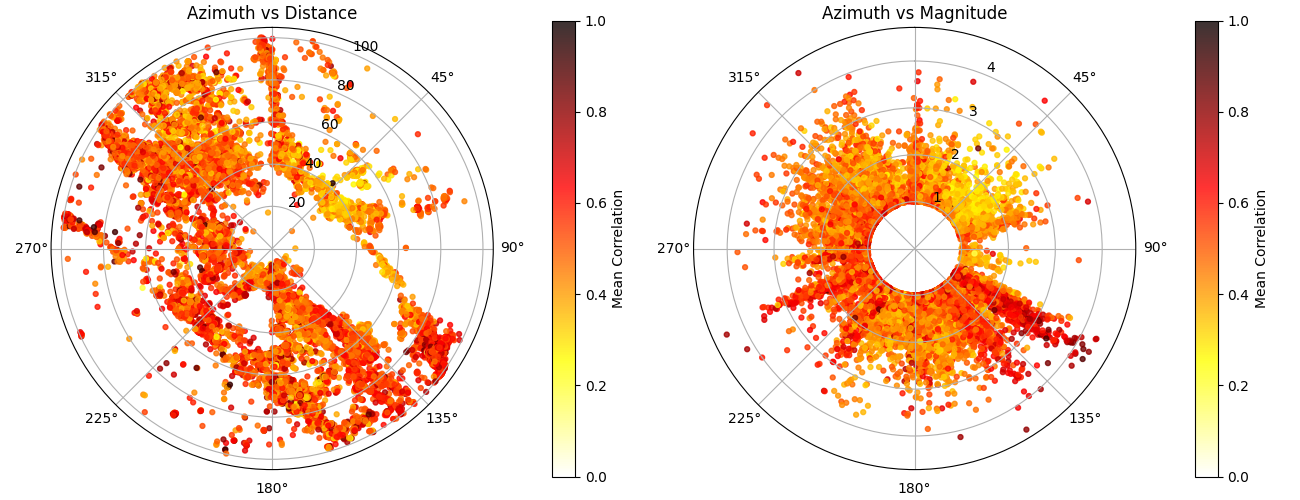

In [9]:
%%time
# Add azimuth and magnitude back into corr_df from meta_df
plot_df = corr_df.copy()
plot_df["EVID"] = plot_df["EVID"].astype(str).str.replace(r"\.0$", "", regex=True)

meta_plot = meta_df_filtered.copy()
meta_plot["EVID"] = meta_plot["EVID"].astype(str).str.replace(r"\.0$", "", regex=True)

plot_df = plot_df.merge(
    meta_plot[["EVID"]],
    on="EVID",
    how="left"
)
plot_df = plot_df.dropna(subset=["azimuth_deg", "distance_km", "MAG", "mean_corr"]).copy()
plot_df["azimuth_deg"] = np.mod(plot_df["azimuth_deg"], 360.0)
plot_df["theta"] = np.deg2rad(plot_df["azimuth_deg"])

ticks = np.arange(0, 360, 45)
labels = ["" if t == 0 else f"{t}°" for t in ticks]

fig, ax = plt.subplots(1, 2, figsize=(13, 5), subplot_kw={"projection": "polar"})

sc1 = ax[0].scatter(
    plot_df["theta"], plot_df["distance_km"],
    c=plot_df["mean_corr"], cmap="hot_r", s=12.5, alpha=0.8, vmin=0, vmax=1
)
ax[0].set_theta_zero_location("N")
ax[0].set_theta_direction(-1)
ax[0].set_thetagrids(ticks, labels)
ax[0].set_title("Azimuth vs Distance")
cb1 = plt.colorbar(sc1, ax=ax[0], pad=0.10)
cb1.set_label("Mean Correlation")

sc2 = ax[1].scatter(
    plot_df["theta"], plot_df["MAG"],
    c=plot_df["mean_corr"], cmap="hot_r", s=12.5, alpha=0.8, vmin=0, vmax=1
)
ax[1].set_theta_zero_location("N")
ax[1].set_theta_direction(-1)
ax[1].set_thetagrids(ticks, labels)
ax[1].set_title("Azimuth vs Magnitude")
cb2 = plt.colorbar(sc2, ax=ax[1], pad=0.10)
cb2.set_label("Mean Correlation")

plt.tight_layout()

fig.savefig(fname="Figures/Singleband_Coherence_Rose_Plots_10Hz.png", dpi=300)

---
Multi-band coherence plots

In [11]:
%%time
# --------------------------------------------------
# Config
# --------------------------------------------------
components = ["BHZ", "BHN", "BHE"]
component_to_use = "BHZ"
comp_idx = components.index(component_to_use)

fs = 40.0
eps = 1e-10

# Use all events, or set to an integer like 1000 if you want a subset
sample_n = X_05_5.shape[0]
random_seed = 42

bands = [
    (0.5, 1.0),
    (1.0, 2.0),
    (2.0, 5.0),
    (5.0, 10.0)
]

# Distance binning
distance_bin_width_km = 25.0

assert len(meta_df_filtered) == X_05_5.shape[0], "meta_df and X are not aligned"

# --------------------------------------------------
# Sampling
# --------------------------------------------------
rng = np.random.default_rng(random_seed)
n_total = X_05_5.shape[0]
n_use = min(sample_n, n_total)
sample_idx = np.sort(rng.choice(n_total, size=n_use, replace=False))

X_sub = X_05_5[sample_idx]
meta_sub = meta_df_filtered.iloc[sample_idx].reset_index(drop=True)

print(f"Using {n_use} events out of {n_total}")

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def norm_xcorr(t_data, data1, data2):
    a = data1
    b = data2

    std_a = np.std(a)
    std_b = np.std(b)

    if std_a < eps or std_b < eps:
        return None, None

    a = (a - np.mean(a)) / (std_a * len(a))
    b = (b - np.mean(b)) / std_b
    x_corr = np.correlate(a, b, "full")
    lags = np.hstack((np.flipud(-t_data)[0:len(t_data)-1], t_data))

    return lags, x_corr

def fix_lengths(t, y):
    t_out = t.copy()
    y_out = y.copy()

    if len(t_out) > len(y_out):
        t_out = t_out[:len(y_out)]
    elif len(y_out) > len(t_out):
        y_out = y_out[:len(t_out)]

    return t_out, y_out

def bandpass_array(data_2d, fs, fmin, fmax, order=4):
    """
    data_2d shape: [n_stations, n_samples]
    """
    sos = butter(order, [fmin, fmax], btype="bandpass", fs=fs, output="sos")
    return sosfiltfilt(sos, data_2d, axis=-1)

def event_full_window_coherence(data_array, fs):
    """
    data_array: [n_stations, n_samples]
    returns one scalar coherence value for the full event window
    """
    n_stations, n_samples = data_array.shape
    t = np.arange(0, n_samples / fs, 1.0 / fs)

    # Match your normalization before xcorr
    data_array_tmp = []
    for i in range(n_stations):
        x = data_array[i]
        mx = np.max(np.abs(x))
        if mx < eps:
            return np.nan
        data_array_tmp.append(x / mx)
    data_array_tmp = np.asarray(data_array_tmp)

    data_fixed = []
    for i in range(data_array_tmp.shape[0]):
        t_use, x_use = fix_lengths(t, data_array_tmp[i])
        data_fixed.append(x_use)
    data_fixed = np.asarray(data_fixed)

    station_means = []
    for tr_idx in range(data_fixed.shape[0]):
        tr_data_idx = data_fixed[tr_idx]
        tr_xcorr_coef = []

        for j in range(data_fixed.shape[0]):
            if j == tr_idx:
                continue

            _, xcorr_vals = norm_xcorr(t_use, tr_data_idx, data_fixed[j])
            if xcorr_vals is None:
                continue
            tr_xcorr_coef.append(np.max(xcorr_vals))

        if len(tr_xcorr_coef) > 0:
            station_means.append(np.mean(tr_xcorr_coef))

    if len(station_means) == 0:
        return np.nan

    return float(np.mean(station_means))

# --------------------------------------------------
# Compute per-event coherence in each band
# --------------------------------------------------
rows = []

for i in range(X_sub.shape[0]):
    event_data = X_sub[i, comp_idx, :, :]   # [n_stations, n_samples]
    meta = meta_sub.iloc[i]

    distance_km = pd.to_numeric(meta["distance_km"], errors="coerce")
    if pd.isna(distance_km):
        continue

    for fmin, fmax in bands:
        try:
            data_bp = bandpass_array(event_data, fs, fmin, fmax)
            mean_corr = event_full_window_coherence(data_bp, fs)
        except Exception:
            mean_corr = np.nan

        rows.append({
            "EVID": meta["EVID"],
            "distance_km": distance_km,
            "band_label": f"{fmin:g}-{fmax:g} Hz",
            "fmin": fmin,
            "fmax": fmax,
            "mean_corr": mean_corr,
        })

    print(f"done with event {i+1}/{X_sub.shape[0]}")

corr_df = pd.DataFrame(rows)
display(corr_df.head())

# --------------------------------------------------
# Bin by distance and compute mean coherence
# --------------------------------------------------
max_dist = np.nanmax(corr_df["distance_km"])
bin_edges = np.arange(0, max_dist + distance_bin_width_km, distance_bin_width_km)

corr_df["distance_bin"] = pd.cut(
    corr_df["distance_km"],
    bins=bin_edges,
    include_lowest=True,
    right=False
)

# Bin centers for plotting
bin_centers = {
    interval: interval.left + (interval.right - interval.left) / 2
    for interval in corr_df["distance_bin"].dropna().unique()
}

curve_df = (
    corr_df.dropna(subset=["mean_corr", "distance_bin"])
    .groupby(["band_label", "distance_bin"], observed=True, as_index=False)
    .agg(
        mean_coherence=("mean_corr", "mean"),
        n_events=("mean_corr", "size"),
    )
)

curve_df["distance_center_km"] = curve_df["distance_bin"].map(bin_centers)

display(curve_df.head())

Using 30000 events out of 30000
done with event 1/30000
done with event 2/30000
done with event 3/30000
done with event 4/30000
done with event 5/30000
done with event 6/30000
done with event 7/30000
done with event 8/30000
done with event 9/30000
done with event 10/30000
done with event 11/30000
done with event 12/30000
done with event 13/30000
done with event 14/30000
done with event 15/30000
done with event 16/30000
done with event 17/30000
done with event 18/30000
done with event 19/30000
done with event 20/30000
done with event 21/30000
done with event 22/30000
done with event 23/30000
done with event 24/30000
done with event 25/30000
done with event 26/30000
done with event 27/30000
done with event 28/30000
done with event 29/30000
done with event 30/30000
done with event 31/30000
done with event 32/30000
done with event 33/30000
done with event 34/30000
done with event 35/30000
done with event 36/30000
done with event 37/30000
done with event 38/30000
done with event 39/30000
do

,EVID,distance_km,band_label,fmin,fmax,mean_corr
0,15533393,51.866585,0.5-1 Hz,0.5,1.0,0.908779
1,15533393,51.866585,1-2 Hz,1.0,2.0,0.731437
2,15533393,51.866585,2-5 Hz,2.0,5.0,0.447580
3,15533393,51.866585,5-10 Hz,5.0,10.0,0.348059
4,15533473,79.110480,0.5-1 Hz,0.5,1.0,0.913850


,band_label,distance_bin,mean_coherence,n_events,distance_center_km
0,0.5-1 Hz,"[0.0, 25.0)",0.902142,3254,12.5
1,0.5-1 Hz,"[25.0, 50.0)",0.906316,9694,37.5
2,0.5-1 Hz,"[50.0, 75.0)",0.904792,7506,62.5
3,0.5-1 Hz,"[75.0, 100.0)",0.903969,9538,87.5
4,0.5-1 Hz,"[100.0, 125.0)",0.936041,8,112.5


CPU times: user 2h 33min 46s, sys: 8.7 s, total: 2h 33min 55s
Wall time: 2h 33min 40s


CPU times: user 808 ms, sys: 52 ms, total: 860 ms
Wall time: 882 ms


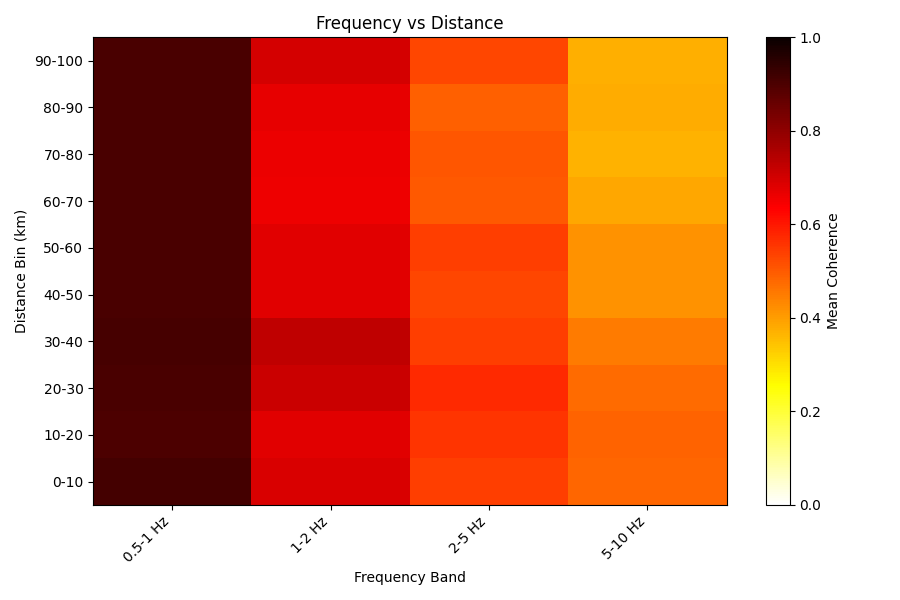

In [12]:
%%time
# -----------------------------------------
# Assumes corr_df already exists with columns:
# ["distance_km", "band_label", "mean_corr"]
# and bands = [(0.5,1.0), (1.0,2.0), (2.0,5.0), (5.0,10.0)]
# -----------------------------------------

distance_bin_width_km = 10.0
max_distance_km = 100.0

# Keep only usable rows and only distances within range
plot_df = corr_df.dropna(subset=["distance_km", "band_label", "mean_corr"]).copy()
plot_df = plot_df[(plot_df["distance_km"] >= 0) & (plot_df["distance_km"] <= max_distance_km)].copy()

# Frequency-band order
band_order = [f"{fmin:g}-{fmax:g} Hz" for fmin, fmax in bands]

# -----------------------------------------
# Manual distance bins
# -----------------------------------------
bin_starts = np.arange(0, max_distance_km, distance_bin_width_km)
distance_label_order = [f"{int(b)}-{int(b + distance_bin_width_km)}" for b in bin_starts]

def assign_distance_bin_label(d):
    if pd.isna(d):
        return np.nan
    if d < 0 or d > max_distance_km:
        return np.nan
    if d == max_distance_km:
        return f"{int(max_distance_km - distance_bin_width_km)}-{int(max_distance_km)}"
    b0 = int(np.floor(d / distance_bin_width_km) * distance_bin_width_km)
    b1 = b0 + int(distance_bin_width_km)
    return f"{b0}-{b1}"

plot_df["distance_bin_label"] = plot_df["distance_km"].apply(assign_distance_bin_label)

# Average coherence in each distance/frequency cell
summary_df = (
    plot_df.groupby(
        ["distance_bin_label", "band_label"],
        observed=True,
        as_index=False
    )
    .agg(
        mean_coherence=("mean_corr", "mean"),
        n_events=("mean_corr", "size")
    )
)

# -----------------------------------------
# Heat map table
# -----------------------------------------
heat_pivot = summary_df.pivot(
    index="distance_bin_label",
    columns="band_label",
    values="mean_coherence"
)

# Enforce consistent ordering
heat_pivot = heat_pivot.reindex(index=distance_label_order, columns=band_order)

# -----------------------------------------
# Plot heat map only
# -----------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    heat_pivot.values,
    aspect="auto",
    origin="lower",
    cmap="hot_r",
    vmin=0,
    vmax=1
)

ax.set_xticks(np.arange(len(heat_pivot.columns)))
ax.set_xticklabels(heat_pivot.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(heat_pivot.index)))
ax.set_yticklabels(heat_pivot.index)

ax.set_xlabel("Frequency Band")
ax.set_ylabel("Distance Bin (km)")
ax.set_title("Frequency vs Distance")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean Coherence")

plt.tight_layout()
fig.savefig(fname="Figures/Multiband_Coherence_Distance_vs_Frequency_10Hz.png", dpi=300)

In [13]:
%%time
results_dir = Path("/users/mronacgiannone/Virtual_Arrays/Database/Coherence_Results")
results_dir.mkdir(parents=True, exist_ok=True)

corr_df.to_pickle(results_dir / "corr_df.pkl")
curve_df.to_pickle(results_dir / "curve_df.pkl")

# Optional: also save as csv for quick inspection
corr_df.to_csv(results_dir / "corr_df.csv", index=False)
curve_df.to_csv(results_dir / "curve_df.csv", index=False)

print(f"Saved: {results_dir / 'corr_df.pkl'}")
print(f"Saved: {results_dir / 'curve_df.pkl'}")

Saved: /users/mronacgiannone/Virtual_Arrays/Database/Coherence_Results/corr_df.pkl
Saved: /users/mronacgiannone/Virtual_Arrays/Database/Coherence_Results/curve_df.pkl
CPU times: user 551 ms, sys: 4.01 ms, total: 555 ms
Wall time: 604 ms


---
Station spacing multi-band coherence

In [6]:
%%time
# --------------------------------------------------
# Config
# --------------------------------------------------
components = ["BHZ", "BHN", "BHE"]
component_to_use = "BHZ"
comp_idx = components.index(component_to_use)

fs = 40.0
eps = 1e-10

# Use all events, or set to an integer like 1000
sample_n = X_05_5.shape[0]
random_seed = 42

bands = [
    (0.5, 1.0),
    (1.0, 2.0),
    (2.0, 5.0),
    (5.0, 10.0),
]

# One site file is enough because geometry is fixed
site_file = Path("/users/mronacgiannone/Virtual_Arrays/PFO.site")

# station_order should match the order used when building X
# If already defined in your notebook, you can remove this line
station_order = [f"BPH{i:02d}" for i in range(1, 14) if f"BPH{i:02d}" not in {"BPH04", "BPH05", "BPH12"}]

assert len(meta_df_filtered) == X_05_5.shape[0], "meta_df and X are not aligned"

# --------------------------------------------------
# Sampling
# --------------------------------------------------
rng = np.random.default_rng(random_seed)
n_total = X_05_5.shape[0]
n_use = min(sample_n, n_total)
sample_idx = np.sort(rng.choice(n_total, size=n_use, replace=False))

X_sub = X_05_5[sample_idx]
meta_sub = meta_df_filtered.iloc[sample_idx].reset_index(drop=True)

print(f"Using {n_use} events out of {n_total}")

# --------------------------------------------------
# Station geometry from .site file
# --------------------------------------------------
site_df = pd.read_csv(
    site_file,
    delim_whitespace=True,
    header=None,
    names=["station", "lat", "lon", "elev"]
)

site_df = site_df[site_df["station"].isin(station_order)].copy()
site_df = site_df.drop_duplicates(subset="station").set_index("station").loc[station_order]

from obspy.geodetics import gps2dist_azimuth

pair_spacing_rows = []
for i in range(len(station_order)):
    for j in range(i + 1, len(station_order)):
        sta_i = station_order[i]
        sta_j = station_order[j]

        lat1, lon1 = site_df.loc[sta_i, ["lat", "lon"]]
        lat2, lon2 = site_df.loc[sta_j, ["lat", "lon"]]

        dist_m, _, _ = gps2dist_azimuth(lat1, lon1, lat2, lon2)

        pair_spacing_rows.append({
            "sta_i": sta_i,
            "sta_j": sta_j,
            "spacing_km": dist_m / 1000.0
        })

pair_spacing_df = pd.DataFrame(pair_spacing_rows)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def norm_xcorr(t_data, data1, data2):
    a = data1
    b = data2

    std_a = np.std(a)
    std_b = np.std(b)

    if std_a < eps or std_b < eps:
        return None, None

    a = (a - np.mean(a)) / (std_a * len(a))
    b = (b - np.mean(b)) / std_b
    x_corr = np.correlate(a, b, "full")
    lags = np.hstack((np.flipud(-t_data)[0:len(t_data)-1], t_data))

    return lags, x_corr

def bandpass_array(data_2d, fs, fmin, fmax, order=4):
    sos = butter(order, [fmin, fmax], btype="bandpass", fs=fs, output="sos")
    return sosfiltfilt(sos, data_2d, axis=-1)

def pairwise_max_xcorrs(data_array, fs, station_order):
    """
    data_array: [n_stations, n_samples]
    Returns a dataframe with one row per station pair.
    """
    n_stations, n_samples = data_array.shape
    t = np.arange(0, n_samples / fs, 1.0 / fs)

    # Match your trace normalization before xcorr
    data_norm = []
    for i in range(n_stations):
        x = data_array[i]
        mx = np.max(np.abs(x))
        if mx < eps:
            return None
        data_norm.append(x / mx)
    data_norm = np.asarray(data_norm)

    rows = []
    for i in range(n_stations):
        for j in range(i + 1, n_stations):
            sta_i = station_order[i]
            sta_j = station_order[j]

            _, xcorr_vals = norm_xcorr(t, data_norm[i], data_norm[j])
            if xcorr_vals is None:
                pair_corr = np.nan
            else:
                pair_corr = float(np.max(xcorr_vals))

            rows.append({
                "sta_i": sta_i,
                "sta_j": sta_j,
                "pair_corr": pair_corr
            })

    return pd.DataFrame(rows)

# --------------------------------------------------
# Compute pairwise correlation database
# --------------------------------------------------
pair_rows = []

for i in range(X_sub.shape[0]):
    event_data = X_sub[i, comp_idx, :, :]   # [n_stations, n_samples]
    meta = meta_sub.iloc[i]

    for fmin, fmax in bands:
        try:
            data_bp = bandpass_array(event_data, fs, fmin, fmax)
            pair_df = pairwise_max_xcorrs(data_bp, fs, station_order)
            if pair_df is None:
                continue

            pair_df = pair_df.merge(pair_spacing_df, on=["sta_i", "sta_j"], how="left")
            pair_df["EVID"] = meta["EVID"]
            pair_df["band_label"] = f"{fmin:g}-{fmax:g} Hz"
            pair_df["fmin"] = fmin
            pair_df["fmax"] = fmax

            pair_rows.append(pair_df)

        except Exception:
            continue

    print(f"done with event {i+1}/{X_sub.shape[0]}")

pair_corr_df = pd.concat(pair_rows, ignore_index=True)
display(pair_corr_df.head())

# Saving
results_dir = Path("/users/mronacgiannone/Virtual_Arrays/Database/Coherence_Results")
results_dir.mkdir(parents=True, exist_ok=True)

pair_corr_df.to_pickle(results_dir / "pair_corr_df.pkl")
pair_corr_df.to_csv(results_dir / "pair_corr_df.csv", index=False)

print(f"Saved: {results_dir / 'pair_corr_df.pkl'}")
print(f"Saved: {results_dir / 'pair_corr_df.csv'}")

Using 30000 events out of 30000
done with event 1/30000


<timed exec>:47: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead


done with event 2/30000
done with event 3/30000
done with event 4/30000
done with event 5/30000
done with event 6/30000
done with event 7/30000
done with event 8/30000
done with event 9/30000
done with event 10/30000
done with event 11/30000
done with event 12/30000
done with event 13/30000
done with event 14/30000
done with event 15/30000
done with event 16/30000
done with event 17/30000
done with event 18/30000
done with event 19/30000
done with event 20/30000
done with event 21/30000
done with event 22/30000
done with event 23/30000
done with event 24/30000
done with event 25/30000
done with event 26/30000
done with event 27/30000
done with event 28/30000
done with event 29/30000
done with event 30/30000
done with event 31/30000
done with event 32/30000
done with event 33/30000
done with event 34/30000
done with event 35/30000
done with event 36/30000
done with event 37/30000
done with event 38/30000
done with event 39/30000
done with event 40/30000
done with event 41/30000
done wit

,sta_i,sta_j,pair_corr,spacing_km,EVID,band_label,fmin,fmax
0,BPH01,BPH02,0.997527,0.064065,15533393,0.5-1 Hz,0.5,1.0
1,BPH01,BPH03,0.994524,0.088732,15533393,0.5-1 Hz,0.5,1.0
2,BPH01,BPH06,0.971007,0.283700,15533393,0.5-1 Hz,0.5,1.0
3,BPH01,BPH07,0.956190,0.322074,15533393,0.5-1 Hz,0.5,1.0
4,BPH01,BPH08,0.976398,0.227378,15533393,0.5-1 Hz,0.5,1.0


Saved: /users/mronacgiannone/Virtual_Arrays/Database/Coherence_Results/pair_corr_df.pkl
Saved: /users/mronacgiannone/Virtual_Arrays/Database/Coherence_Results/pair_corr_df.csv
CPU times: user 1h 24min 44s, sys: 14.5 s, total: 1h 24min 58s
Wall time: 1h 24min 49s


CPU times: user 1.41 s, sys: 771 ms, total: 2.18 s
Wall time: 2.26 s


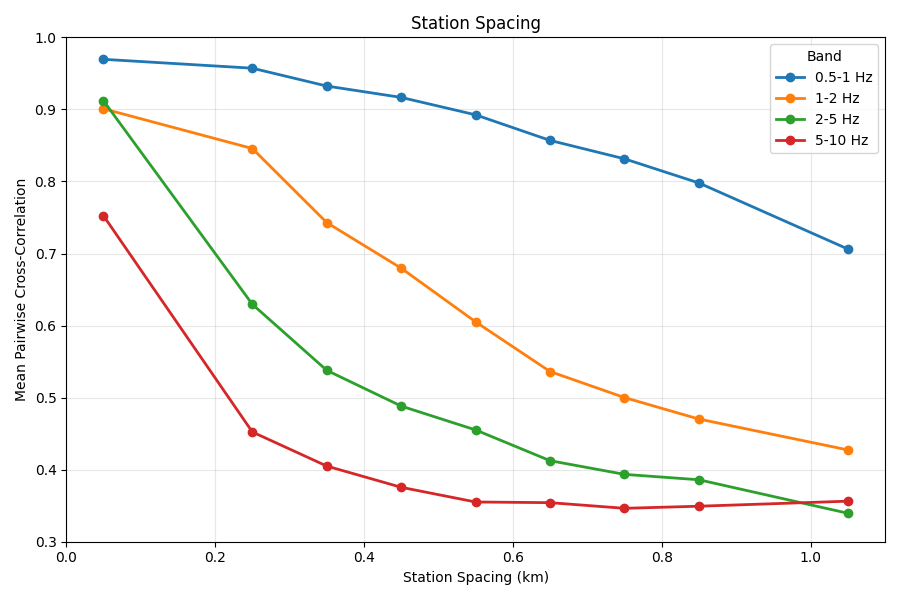

In [7]:
%%time
spacing_bin_width_km = 0.1

plot_df = pair_corr_df.dropna(subset=["spacing_km", "pair_corr"]).copy()
max_spacing = np.nanmax(plot_df["spacing_km"])
bin_edges = np.arange(0, max_spacing + spacing_bin_width_km, spacing_bin_width_km)

plot_df["spacing_bin"] = pd.cut(
    plot_df["spacing_km"],
    bins=bin_edges,
    include_lowest=True,
    right=False
)

plot_df["spacing_center_km"] = plot_df["spacing_bin"].apply(
    lambda x: x.left + (x.right - x.left) / 2 if pd.notna(x) else np.nan
)

summary_df = (
    plot_df.groupby(["band_label", "spacing_bin", "spacing_center_km"], observed=True, as_index=False)
    .agg(mean_pair_corr=("pair_corr", "mean"))
)

fig = plt.figure(figsize=(9, 6))

for fmin, fmax in bands:
    band_label = f"{fmin:g}-{fmax:g} Hz"
    df_band = summary_df[summary_df["band_label"] == band_label].sort_values("spacing_center_km")

    plt.plot(
        df_band["spacing_center_km"],
        df_band["mean_pair_corr"],
        marker="o",
        linewidth=2,
        label=band_label
    )

plt.xlim([0,1.1]), plt.ylim([0.3,1])
plt.xlabel("Station Spacing (km)")
plt.ylabel("Mean Pairwise Cross-Correlation")
plt.title("Station Spacing")
plt.grid(True, alpha=0.3)
plt.legend(title="Band", loc="upper right", fontsize=10, title_fontsize=10)
plt.tight_layout()
fig.savefig(fname="Figures/Multiband_Station_Spacing_10Hz.png", dpi=300)

---
Train/test split

In [5]:
%%time
test_size = 0.20
random_state = 42

indices = np.arange(X_05_5.shape[0])

idx_train, idx_test = train_test_split(
    indices,
    test_size=test_size,
    random_state=random_state,
    shuffle=True
)

X_train = X_05_5[idx_train]
X_test = X_05_5[idx_test]

meta_train = meta_df_filtered.iloc[idx_train].reset_index(drop=True)
meta_test = meta_df_filtered.iloc[idx_test].reset_index(drop=True)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (24000, 3, 10, 2400)
Test shape: (6000, 3, 10, 2400)
CPU times: user 484 ms, sys: 656 ms, total: 1.14 s
Wall time: 1.14 s


In [6]:
%%time
# Saving
local_preproc_dir = Path("Database/Preprocessed")
local_preproc_dir.mkdir(parents=True, exist_ok=True)

# Keep waveform arrays compact
X_train = X_train.astype(np.float32, copy=False)
X_test = X_test.astype(np.float32, copy=False)

items_to_save = [
    ("X_train10.npy", X_train),
    ("X_test10.npy", X_test),
]

for fname, arr in items_to_save:
    arr = np.asarray(arr)
    print(f"Saving {fname} | shape={arr.shape} | dtype={arr.dtype} | size={arr.nbytes/1e9:.2f} GB")
    t0 = time.time()
    np.save(local_preproc_dir / fname, arr, allow_pickle=False)
    print(f"Finished {fname} in {time.time() - t0:.1f} s")

print("Saving meta_train.pkl")
t0 = time.time()
meta_train.to_pickle(local_preproc_dir / "meta_train.pkl")
print(f"Finished meta_train.pkl in {time.time() - t0:.1f} s")

print("Saving meta_test.pkl")
t0 = time.time()
meta_test.to_pickle(local_preproc_dir / "meta_test.pkl")
print(f"Finished meta_test.pkl in {time.time() - t0:.1f} s")

print("Saved preprocessed split to:", local_preproc_dir)

Saving X_train10.npy | shape=(24000, 3, 10, 2400) | dtype=float32 | size=6.91 GB
Finished X_train10.npy in 13.6 s
Saving X_test10.npy | shape=(6000, 3, 10, 2400) | dtype=float32 | size=1.73 GB
Finished X_test10.npy in 2.8 s
Saving meta_train.pkl
Finished meta_train.pkl in 0.0 s
Saving meta_test.pkl
Finished meta_test.pkl in 0.0 s
Saved preprocessed split to: Database/Preprocessed
CPU times: user 465 ms, sys: 5.58 s, total: 6.05 s
Wall time: 16.4 s


In [10]:
# Checking magnitudes
mag_threshold = 2.0

train_mags = meta_train["MAG"].to_numpy(dtype=np.float32)
test_mags = meta_test["MAG"].to_numpy(dtype=np.float32)

base_large_frac_train = np.mean(train_mags >= mag_threshold)
base_large_frac_test = np.mean(test_mags >= mag_threshold)

print(f"Base train fraction with MAG >= {mag_threshold}: {base_large_frac_train:.4f}")
print(f"Base test fraction with MAG >= {mag_threshold}: {base_large_frac_test:.4f}")
print(f"Train large-event count: {np.sum(train_mags >= mag_threshold)} / {len(train_mags)}")
print(f"Test large-event count: {np.sum(test_mags >= mag_threshold)} / {len(test_mags)}")

Base train fraction with MAG >= 2.0: 0.1018
Base test fraction with MAG >= 2.0: 0.1118
Train large-event count: 2444 / 24000
Test large-event count: 671 / 6000


---
Plot the array data for test events

In [4]:
%%time
# Download dataset from SSD
db_dir = Path("Database/Preprocessed")
X_test = np.load(db_dir / "X_test10.npy")
meta_test = pd.read_pickle(db_dir / "meta_test.pkl").reset_index(drop=True)

# print("Number of events in train set: " + str(X_train.shape[0]))
print("Number of events in test set: " + str(X_test.shape[0]))
print("Each event has input of shape: [" + str(X_test.shape[1]) + ", " + str(X_test.shape[2]) + ", " + str(X_test.shape[3]) + "]")

Number of events in test set: 6000
Each event has input of shape: [3, 10, 2400]
CPU times: user 86 ms, sys: 1.06 s, total: 1.15 s
Wall time: 9.38 s


In [ ]:
%%time
%matplotlib agg

# Plot and save array data for each test event without rendering in notebook

array_plot_dir = Path("/Volumes/PortableSSD/Data/Virtual_Arrays/PFO/Earthquakes/test_events/array_data/") # IMPORTANT: change this directory to where you would like the test events to plot
array_plot_dir.mkdir(parents=True, exist_ok=True)

stations_to_remove = {"BPH04", "BPH05", "BPH12"}

station_order = [
    f"BPH{i:02d}"
    for i in range(1, 14)
    if f"BPH{i:02d}" not in stations_to_remove
]

max_events = None
start_event = 0
dpi = 200

components = ["BHZ", "BHN", "BHE"]
fs = 40.0
bandpass = [0.5, 5]
normalize_traces = True

n_events = X_test.shape[0]
stop_event = n_events if max_events is None else min(start_event + max_events, n_events)

print(f"Saving test-event array plots for events {start_event} to {stop_event - 1}")
print(f"Output directory: {array_plot_dir.resolve()}")

for event_idx in range(start_event, stop_event):
    event_meta = meta_test.iloc[event_idx] if meta_test is not None else {}

    evid = event_meta.get("EVID", event_idx) if hasattr(event_meta, "get") else event_idx
    evid_str = str(evid).replace(".0", "")

    safe_evid = "".join(
        ch if ch.isalnum() or ch in ["-", "_"] else "_"
        for ch in evid_str
    )

    fig, axes = plot_event_waveforms(
        X_test,
        event_idx=event_idx,
        station_order=station_order,
        components=components,
        fs=fs,
        meta_df=meta_test,
        bandpass=bandpass,
        normalize_traces=normalize_traces,
    )

    out_file = array_plot_dir / f"test_event_{event_idx:05d}_EVID_{safe_evid}.png"
    fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    if (event_idx - start_event + 1) % 100 == 0:
        print(f"Saved {event_idx - start_event + 1} / {stop_event - start_event} plots")

print(f"Done. Saved {stop_event - start_event} figures to {array_plot_dir.resolve()}")